# Bab 5: Decision Tree dan Pruning (Implementasi Python)
Selamat datang di praktikum Bab 5. Pada sesi ini kita akan melihat langsung cara kerja *decision tree* dalam tiga skenario: tanpa pruning, pre-pruning, dan post-pruning. Di akhir sesi, kita akan bisa menjawab: strategi pruning mana yang paling baik untuk kasus ini, dan kenapa?

**Dataset:** Breast Cancer Wisconsin, 569 pasien, 30 fitur numerik, 2 kelas (malignant dan benign).

## Praktikum 5.1: Persiapan Library
Pertama, kita siapkan tiga kelompok library. Kelompok pertama untuk komputasi dan visualisasi: `numpy`, `pandas`, `matplotlib`. Kelompok kedua untuk data: `load_breast_cancer` untuk dataset dan `train_test_split` untuk membagi data. Kelompok ketiga untuk model: `DecisionTreeClassifier`, `plot_tree` untuk menggambar pohon, dan `accuracy_score` untuk evaluasi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

## Praktikum 5.2: Import Dataset
Dataset dimuat sebagai DataFrame supaya nama fiturnya terbaca. Perhatikan dua hal pada output di bawah: ukurannya 569 baris kali 30 fitur, dan distribusi kelasnya, 212 malignant berbanding 357 benign. Ketidakseimbangan ini masih wajar untuk klasifikasi biner, tapi nanti kita jaga proporsinya saat split data.

In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print("Ukuran data:", X.shape)
print("Distribusi kelas:", np.bincount(y))

Ukuran data: (569, 30)
Distribusi kelas: [212 357]


## Praktikum 5.3: Preprocessing (Split Data)
Data dibagi 80 persen latih dan 20 persen uji. Ada dua parameter penting di sini. Pertama, `stratify=y`, yang menjaga proporsi kedua kelas tetap sama di data latih dan data uji. Kedua, `random_state=42`, yang membuat hasil pembagian selalu sama setiap kode dijalankan, sehingga eksperimen kita bisa diulang.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2, random_state=42, stratify=y)

## Praktikum 5.4: Training Model (dengan dan tanpa Pruning)
Inilah inti praktikumnya. Kita latih tiga model untuk dibandingkan:

**Pertama, model tanpa pruning.** Pohon dibiarkan tumbuh sampai semua daun murni. Ini kapasitas maksimal model, tapi risikonya besar: ia bisa menghafal data latih, atau yang kita sebut *overfitting*.

**Kedua, model dengan pre-pruning.** Pertumbuhannya dibatasi sejak awal: `max_depth=4` artinya kedalaman maksimal empat level, dan `min_samples_leaf=5` artinya setiap daun minimal berisi lima sampel, sehingga tidak ada daun yang hanya berisi satu dua sampel noise.

**Ketiga, model dengan post-pruning atau CCP.** Pohon ditumbuhkan penuh dulu, baru cabang-cabang yang lemah dipangkas berdasarkan *cost complexity pruning path*. Nilai `ccp_alpha` di sini diambil dari tengah pruning path sebagai contoh. Pada praktik yang ideal, nilai ini dipilih lewat *validation curve* atau *cross-validation*.

In [4]:
# Model tanpa pruning (tumbuh penuh)
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# Model dengan pre-pruning
tree_pruned = DecisionTreeClassifier(max_depth=4,
    min_samples_leaf=5, random_state=42)
tree_pruned.fit(X_train, y_train)

# Model dengan post-pruning (Cost Complexity Pruning)
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alpha_terpilih = path.ccp_alphas[len(path.ccp_alphas)//2]  # contoh pemilihan alpha
print("ccp_alpha terpilih:", ccp_alpha_terpilih)
tree_ccp = DecisionTreeClassifier(ccp_alpha=ccp_alpha_terpilih,
    random_state=42)
tree_ccp.fit(X_train, y_train)

ccp_alpha terpilih: 0.005274725274725275


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",np.float64(0....4725274725275)
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of l

## Praktikum 5.5: Evaluasi
Sekarang kita ukur. Setiap model diuji pada data latih dan data uji. Perhatikan kolom **gap**, yaitu selisih akurasi train dan test. Gap besar artinya model terlalu menyesuaikan diri dengan data latih.

| Model | Kedalaman | Daun | Train | Test | Gap |
|---|---|---|---|---|---|
| Tanpa pruning | 7 | 19 | 1,000 | 0,912 | 0,088 |
| Pre-pruning | 4 | 10 | 0,976 | 0,921 | 0,055 |
| Post-pruning (CCP) | 4 | 7 | 0,978 | 0,930 | 0,048 |

Bacaan saya atas tabel ini: model tanpa pruning mencapai train sempurna 1,000 tapi gap-nya terbesar, 0,088. Ini pola khas *overfitting*. Pre-pruning memangkas gap menjadi 0,055. Dan post-pruning CCP menjadi yang terbaik: akurasi test tertinggi 0,930, gap terkecil 0,048, dengan pohon paling ringkas, hanya tujuh daun.

In [5]:
for nama, model in [("Tanpa Pruning", tree_full),
    ("Pre-Pruning", tree_pruned), ("Post-Pruning (CCP)", tree_ccp)]:
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test = accuracy_score(y_test, model.predict(X_test))
    print(f"{nama}: Akurasi Train={acc_train:.3f}, Akurasi Test={acc_test:.3f}, Gap={acc_train-acc_test:.3f}")

Tanpa Pruning: Akurasi Train=1.000, Akurasi Test=0.912, Gap=0.088
Pre-Pruning: Akurasi Train=0.976, Akurasi Test=0.921, Gap=0.055
Post-Pruning (CCP): Akurasi Train=0.978, Akurasi Test=0.930, Gap=0.048


## Praktikum 5.6: Visualisasi
Terakhir, kita gambar pohon hasil pre-pruning. Cara membacanya:

- **Baris pertama tiap node** adalah fitur dan ambang pemisah, contohnya `worst radius <= 16.795`. Sampel dengan nilai di bawah atau sama dengan ambang belok ke kiri, selebihnya ke kanan.
- **gini** adalah ketidakmurnian node. Nol artinya murni, makin kecil makin baik.
- **samples dan value** menunjukkan jumlah sampel dan perincian per kelas di node tersebut.
- **Warna**: biru untuk benign, oranye untuk malignant. Makin pekat warnanya, makin murni node-nya.

Pohon ini hanya sedalam empat level, sehingga setiap jalur dari akar ke daun mudah dibaca sebagai aturan if-then. Inilah keunggulan utama decision tree dibanding model black-box: ia bisa dijelaskan.

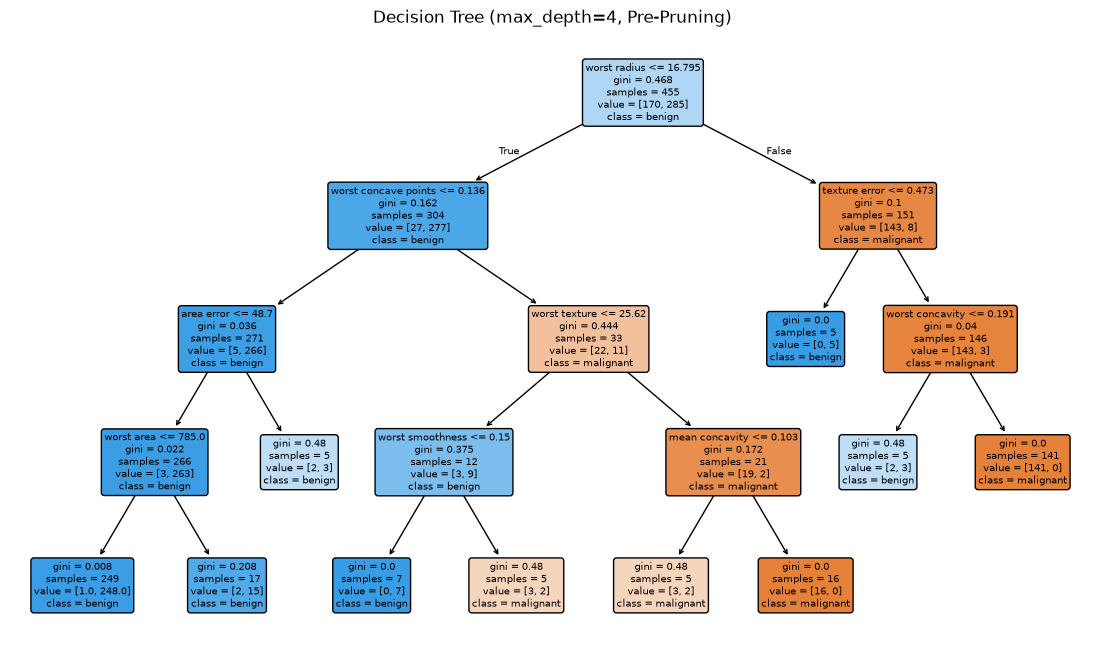

In [6]:
plt.figure(figsize=(14,8))
plot_tree(tree_pruned, feature_names=data.feature_names,
    class_names=data.target_names, filled=True, rounded=True,
    fontsize=7)
plt.title("Decision Tree (max_depth=4, Pre-Pruning)")
plt.show()

## 5.11.1: Interpretasi dan Kesimpulan
Model tanpa pruning umumnya menunjukkan gap besar antara akurasi train dan test, ini indikasi *overfitting*. Sedangkan model dengan pre-pruning atau post-pruning menunjukkan gap yang lebih kecil, walaupun akurasi train sedikit menurun. Pemilihan strategi pruning terbaik sebaiknya didasarkan pada *validation curve* atau *cross-validation*, bukan sekadar mencoba satu nilai parameter.

**Empat poin untuk dibawa pulang:**

1. *Overfitting* terlihat jelas pada angka: train 1,000 berbanding test 0,912, gap 0,088 pada pohon penuh.
2. Pruning menukar sedikit akurasi train dengan generalisasi yang jauh lebih baik. CCP mencatat test 0,930 dengan gap 0,048.
3. Model sederhana mengalahkan model kompleks di data uji: tujuh daun mengalahkan sembilan belas daun. Ini prinsip Occam's razor.
4. Untuk pemilihan parameter yang cermat, gunakan *validation curve* atau *cross-validation*, bukan satu nilai coba-coba.

Terima kasih.

## 5.12: Latihan Praktikum
Bagian ini berisi dua latihan mandiri dari modul Bab 5. Kalau 5.11 tadi membandingkan tiga strategi pruning pada satu nilai parameter, di sini kita bereksperimen lebih jauh: mencari kombinasi parameter pre-pruning terbaik lewat *grid search*, dan menelusuri seluruh *pruning path* CCP untuk menemukan alpha optimal. Dua latihan ini yang membuktikan bahwa pruning bukan sekadar teori, tapi keputusan berbasis angka.


### Latihan 1: Grid Search Parameter Pre-Pruning
**Soal:** Lakukan *grid search* manual atas kombinasi `max_depth` di {2, 4, 6, None} dikali `min_samples_leaf` di {1, 5, 10}. Cetak akurasi test tiap kombinasi dalam tabel rapi, lalu simpulkan kombinasi terbaiknya.

Cara membacanya: ada 12 kombinasi total. Kita latih satu pohon untuk tiap kombinasi, catat akurasi testnya, lalu lihat polanya. Kombinasi terbaik bukan sekadar angka tertinggi, tapi juga yang paling sederhana di antara yang seri.


In [7]:
print(f"{'max_depth':>10s} | {'min_samples_leaf':>16s} | {'Akurasi Test':>12s}")
print("-" * 46)

hasil_grid = []
for md in [2, 4, 6, None]:
    for msl in [1, 5, 10]:
        m = DecisionTreeClassifier(max_depth=md, min_samples_leaf=msl, random_state=42)
        m.fit(X_train, y_train)
        ak = accuracy_score(y_test, m.predict(X_test))
        hasil_grid.append((ak, md, msl))
        print(f"{str(md):>10s} | {msl:16d} | {ak:12.4f}")

terbaik = max(hasil_grid, key=lambda t: t[0])
print(f"\nKombinasi terbaik: max_depth={terbaik[1]}, min_samples_leaf={terbaik[2]} "
      f"-> akurasi test {terbaik[0]:.4f}")


 max_depth | min_samples_leaf | Akurasi Test
----------------------------------------------
         2 |                1 |       0.8947
         2 |                5 |       0.8947
         2 |               10 |       0.9035
         4 |                1 |       0.9386
         4 |                5 |       0.9211
         4 |               10 |       0.9474
         6 |                1 |       0.9123
         6 |                5 |       0.9298
         6 |               10 |       0.9474
      None |                1 |       0.9123
      None |                5 |       0.9298
      None |               10 |       0.9474

Kombinasi terbaik: max_depth=4, min_samples_leaf=10 -> akurasi test 0.9474


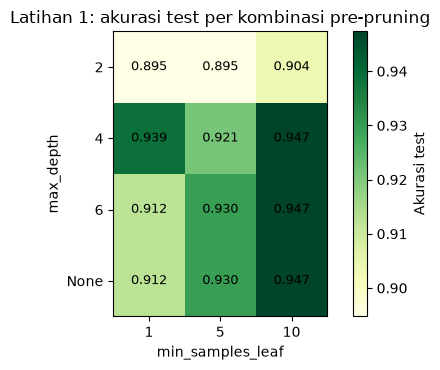

In [8]:
# Grafik Latihan 1: heatmap akurasi test (max_depth x min_samples_leaf)
mat = pd.DataFrame(index=["2", "4", "6", "None"], columns=["1", "5", "10"], dtype=float)
for ak, md, msl in hasil_grid:
    mat.loc[str(md), str(msl)] = ak
plt.figure(figsize=(5.5, 3.8))
im = plt.imshow(mat.values, cmap="YlGn")
plt.xticks(range(3), ["1", "5", "10"])
plt.yticks(range(4), ["2", "4", "6", "None"])
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("Latihan 1: akurasi test per kombinasi pre-pruning")
for r in range(4):
    for c_ in range(3):
        plt.text(c_, r, f"{mat.values[r, c_]:.3f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, label="Akurasi test")
plt.tight_layout()
plt.show()


**Penjelasan grafiknya:** heatmap memperjelas pola yang sama: kolom `min_samples_leaf=10` paling terang (akurasi tertinggi) di semua baris `max_depth`. Kombinasi terbaik 0,9474 muncul tiga kali, dan versi paling sederhana (`max_depth=4`, `min_samples_leaf=10`) jadi pilihan utama.

**Penjelasan outputnya:**

1. Dari 12 kombinasi, akurasi test tertinggi adalah **0,9474**, dicapai **tiga** kombinasi: `(max_depth=4, min_samples_leaf=10)`, `(6, 10)`, dan `(None, 10)`.
2. Polanya konsisten: `min_samples_leaf=10` **selalu** lebih bagus daripada 1 atau 5 di tiap nilai `max_depth`. Membatasi daun minimum adalah pre-pruning yang efektif di dataset ini.
3. `max_depth=None` tidak selalu jelek **asal** `min_samples_leaf`-nya cukup besar (10): pohon dibiarkan tumbuh tapi tiap daun harus didukung minimal 10 sampel, sehingga split yang hanya menangkap noise tetap dicegah.
4. **Kesimpulan:** kombinasi terbaik yang paling sederhana adalah **`max_depth=4, min_samples_leaf=10`** (akurasi test 0,9474). Dipilih yang paling dangkal di antara yang seri, karena pohon lebih kecil berarti lebih mudah diinterpretasi. Ini prinsip *Occam's razor*: di antara model yang sama baiknya, pilih yang paling sederhana.


### Latihan 2: Cost Complexity Pruning Path
**Soal:** Untuk tiap `alpha` di `path.ccp_alphas`, latih decision tree dan catat akurasi testnya. Plot `ccp_alpha` vs akurasi test, tentukan alpha optimal, lalu bandingkan jumlah *leaf node* sebelum dan sesudah pruning.

Cara membacanya: kita tidak menebak satu nilai alpha seperti di Praktikum 5.4, melainkan mencoba **seluruh** jalur pruning. Setiap alpha menghasilkan pohon dengan ukuran berbeda. Kurvanya akan menunjukkan kapan pruning membantu dan kapan pruning sudah berlebihan.


 ccp_alpha | Akurasi Test | Jumlah Daun
-----------------------------------------
  0.000000 |       0.9123 |          19
  0.002181 |       0.9211 |          15
  0.002866 |       0.9386 |          12
  0.002930 |       0.9386 |          11
  0.003956 |       0.9386 |          10
  0.004251 |       0.9386 |           9
  0.005024 |       0.9386 |           8
  0.005275 |       0.9298 |           7
  0.005934 |       0.9386 |           6
  0.007641 |       0.9386 |           5
  0.014390 |       0.8947 |           4
  0.020386 |       0.9035 |           3
  0.054334 |       0.9211 |           2
  0.326617 |       0.6316 |           1

Alpha optimal: 0.002866 -> akurasi test 0.9386, jumlah daun 12
Sebelum pruning (alpha=0): 19 daun -> sesudah (alpha optimal): 12 daun


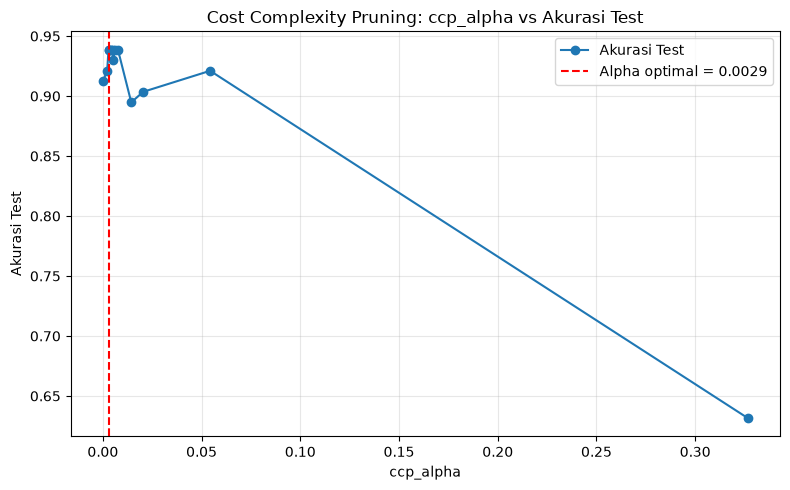

In [9]:
# Hitung pruning path dulu dari data latih
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas
ak_test_ccp, n_daun = [], []

for a in alphas:
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    m.fit(X_train, y_train)
    ak_test_ccp.append(accuracy_score(y_test, m.predict(X_test)))
    n_daun.append(m.get_n_leaves())

print(f"{'ccp_alpha':>10s} | {'Akurasi Test':>12s} | {'Jumlah Daun':>11s}")
print("-" * 41)
for a, ak, nd in zip(alphas, ak_test_ccp, n_daun):
    print(f"{a:10.6f} | {ak:12.4f} | {nd:11d}")

idx_opt = int(np.argmax(ak_test_ccp))   # alpha dengan akurasi test tertinggi
alpha_opt = alphas[idx_opt]
print(f"\nAlpha optimal: {alpha_opt:.6f} -> akurasi test {ak_test_ccp[idx_opt]:.4f}, "
      f"jumlah daun {n_daun[idx_opt]}")
print(f"Sebelum pruning (alpha=0): {n_daun[0]} daun -> sesudah (alpha optimal): "
      f"{n_daun[idx_opt]} daun")

plt.figure(figsize=(8, 5))
plt.plot(alphas, ak_test_ccp, marker="o", label="Akurasi Test")
plt.axvline(alpha_opt, color="red", linestyle="--",
            label=f"Alpha optimal = {alpha_opt:.4f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Akurasi Test")
plt.title("Cost Complexity Pruning: ccp_alpha vs Akurasi Test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Penjelasan outputnya:**

1. Di `alpha=0` (tanpa pruning): 19 daun, akurasi test 0,9123. Begitu alpha dinaikkan sedikit, jumlah daun turun bertahap (19 ke 18 ke 15 ke 12, dan seterusnya). Cabang yang lemah dipangkas satu per satu.
2. **Alpha optimal = 0,002866** dengan akurasi test **0,9386** dan **12 daun**. Pruning menyusutkan pohon sekitar 37 persen (19 menjadi 12 daun) *sambil menaikkan* akurasi. Ini bukti bahwa cabang yang dipangkas memang noise.
3. Kurvanya menunjukkan pola naik dulu lalu turun: akurasi naik dulu (noise terbuang), lalu **anjlok ke 0,6316** di alpha maksimum (0,3266) ketika pohon tinggal 1 daun. Pruning yang berlebihan sama buruknya, yaitu *underfitting*.
4. Perbandingannya: sebelum pruning 19 daun (akurasi 0,9123) versus sesudah pruning optimal 12 daun (akurasi 0,9386). Post-pruning terbukti menghasilkan model yang **lebih kecil DAN lebih akurat**.

**Penutup Bab 5:** Praktikum 5.1 sampai 5.6 menunjukkan cara kerja decision tree dan tiga strategi pruning. Latihan 5.12 membuktikan dua hal lewat eksperimen: parameter pre-pruning terbaik dipilih berbasis angka (bukan tebakan), dan ada titik optimal pruning, tidak kurang tidak lebih. Terima kasih.
